<a href="https://colab.research.google.com/github/Parinith-git/codsoft_ds_internship/blob/main/Task4-Sales-Prediction/Sales_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/amankharwal/Website-data/master/advertising.csv"
df = pd.read_csv(url)
print("Shape:", df.shape)
df.head()

Shape: (200, 4)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Features and target
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("\nCoefficients:")
for col, coef in zip(X.columns, model.coef_):
    print(f"  {col}: {coef:.4f}")

R2 Score: 0.9059011844150826
RMSE: 1.7052146229349223

Coefficients:
  TV: 0.0545
  Radio: 0.1009
  Newspaper: 0.0043


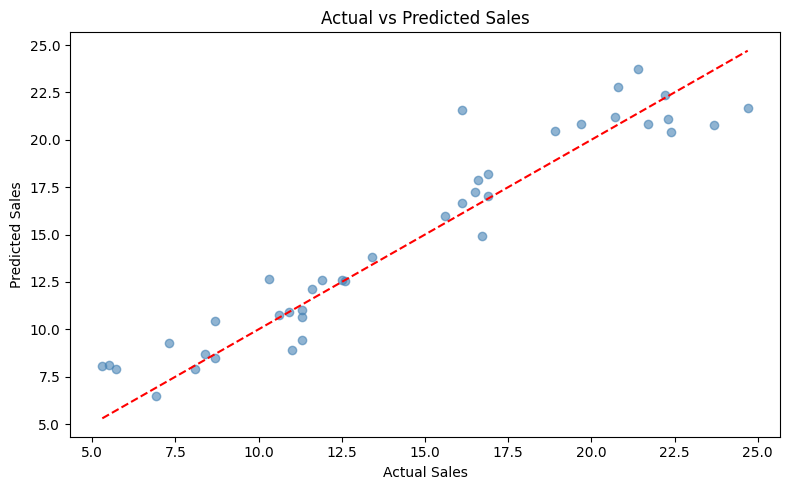

In [5]:
import matplotlib.pyplot as plt

# Plot actual vs predicted
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.tight_layout()
plt.show()